<h1 style="text-align: center; color: green;"> Mini Projet </h1>
<h1 style="text-align: center; color: green;">  Apprentissage Profond</h1>

<h2> Sujet : Détection de Tumeurs Cérébraux à Partir de Images Médicales</h2>

<h2 style="color:#3366cc;">Importation des Bibliothèques</h2>

<p><b>Le code importe diverses bibliothèques et modules TensorFlow, notamment des classes et des fonctions pour le prétraitement d'images, des modèles de réseaux neuronaux comme VGG16 , des optimiseurs, des utilitaires, des couches, des rappels (callbacks), et d'autres modules tels que NumPy, PIL (Pillow), OpenCV, Matplotlib, argparse, et pandas. Ces bibliothèques sont utilisées pour mettre en œuvre un modèle de réseau neuronal convolutionnel (CNN) pour la classification d'images.</b></p>

In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.python.keras import Sequential
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import argparse
import os
import cv2
from tensorflow.keras.regularizers import l1
from tensorflow.keras.regularizers import l2
import pandas as pd
from ipywidgets import FileUpload, Output, VBox, Button
from IPython.display import display, clear_output
import io
from sklearn.utils import shuffle
from tensorflow.keras.callbacks import TensorBoard
import time 
from os import listdir

<h2 style="color:#3366cc;">Définition du Chemin du Dataset</h2>

<p><b>Le code spécifie le chemin du répertoire où se trouve dataset sur les tumeurs cérébrales. </b></p>

In [3]:
chemin_dataset = "./brain_tumor_dataset/"

<h2 style="color:#3366cc;">Affichage des Répertoires dans le Dataset</h2>

<p><b>Le code affiche les répertoires présents dans le dataset en utilisant la fonction os.listdir(chemin_dataset).</b></p>

In [4]:
dirs = os.listdir(chemin_dataset)
for folder in dirs:
    print(folder)

no
yes


<p><b>
Le résultat de l'exécution du code indique la présence de deux répertoires dans le dataset, identifiés comme "yes" et "no".</b></p>

<h2 style="color:#3366cc;">Distribution des Images par Classe</h2>

<p><b>Ce script fournit des informations sur la distribution des images entre les différentes classes du dataset, ainsi que le nombre total d'images dans l'ensemble du dataset.</b></p>

In [5]:
classes = ["yes", "no"]
# Parcourir chaque classe et compter le nombre total d'images
for class_name in classes:
    class_path = os.path.join(chemin_dataset, class_name)
    all_files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    image_count = len(all_files)
    print(f"Le nombre d'images dans la classe '{class_name}' : {image_count}")
# Nombre total d'images dans le dataset
total_images = sum([len(os.listdir(os.path.join(chemin_dataset, class_name))) for class_name in classes])
print(f"Le nombre total d'images dans le dataset : {total_images}")

Le nombre d'images dans la classe 'yes' : 155
Le nombre d'images dans la classe 'no' : 98
Le nombre total d'images dans le dataset : 253


<p><b>Il indique qu'il y a 155 images dans la classe 'yes' et 98 images dans la classe 'no', avec un total de 253 images dans l'ensemble du dataset.</b></p>

<h2 style="color:#3366cc;">Extensions des Images dans les Dossiers 'yes' et 'no'</h2>

In [6]:
yes_path = os.path.join(chemin_dataset, "yes")
no_path = os.path.join(chemin_dataset, "no")

# Afficher les extensions des images dans les deux dossiers
yes_extensions = [img.split(".")[-1] for img in os.listdir(yes_path)]
no_extensions = [img.split(".")[-1] for img in os.listdir(no_path)]

print("\nExtensions des images dans 'yes':\n", set(yes_extensions))
print("Extensions des images dans 'no':\n", set(no_extensions))


Extensions des images dans 'yes':
 {'JPG', 'jpg', 'png'}
Extensions des images dans 'no':
 {'JPG', 'jpeg', 'jpg', 'png'}


<h2 style="color:#3366cc;">Extraction des Dimensions et Tailles des Images</h2>

<p><b>Cette fonction prend un répertoire en entrée, récupère les dimensions et la taille des images (avec certaines informations supplémentaires) dans ce répertoire, puis renvoie ces informations sous la forme d'un DataFrame pandas. Cela peut être utile pour effectuer des analyses ou des traitements statistiques sur les données d'images.</b></p>

In [7]:
all_dimensions = []
for class_name in classes:
    class_path = os.path.join(chemin_dataset, class_name)

    for filename in os.listdir(class_path):
        file_path = os.path.join(class_path, filename)

        try:
            with Image.open(file_path) as img:
                width, height = img.size
                bit_depth = img.info['bit'] if 'bit' in img.info else None
                size_bits = os.path.getsize(file_path) * 8
            all_dimensions.append([filename, height, width, bit_depth, size_bits, class_name])

        except (OSError, IOError, ValueError) as e:
            print(f"Ignoré le fichier {filename} dans la classe {class_name} en raison d'une erreur : {e}")
# Créer un DataFrame avec pandas
columns = ['Filename', 'Height', 'Width', 'Bit Depth', 'Size (bits)', 'Class']
df_combined = pd.DataFrame(all_dimensions, columns=columns)
print("Dimensions des images dans l'ensemble du dataset:")
print(df_combined)

Dimensions des images dans l'ensemble du dataset:
      Filename  Height  Width Bit Depth  Size (bits) Class
0      1_0.jpg     218    180      None        40912   yes
1      1_1.jpg     360    319      None        68248   yes
2     1_10.jpg    1200   1059      None       910744   yes
3    1_100.jpg     360    319      None        68248   yes
4    1_101.jpg     325    300      None       126992   yes
..         ...     ...    ...       ...          ...   ...
248   0_93.jpg     454    442      None      1281048    no
249   0_94.jpg     680    680      None      1601816    no
250   0_95.jpg     444    468      None       226200    no
251   0_96.jpg     442    442      None       282864    no
252   0_97.jpg     449    359      None       293864    no

[253 rows x 6 columns]


<p><b>
Cette fonction parcourt chaque classe du dataset, récupère les dimensions et la taille en bits de chaque image dans ces classes, puis stocke ces informations dans un DataFrame pandas. Le DataFrame résultant, nommé df_combined, contient des colonnes telles que 'Filename' (nom du fichier), 'Height' (hauteur de l'image), 'Width' (largeur de l'image), 'Bit Depth' (profondeur en bits), 'Size (bits)' (taille en bits) et 'Class' (classe de l'image, soit 'yes' ou 'no'). </b></p>

<h2 style="color:#3366cc;">Visualisation Aléatoire d'Échantillons d'Images</h2>

<p><b>La fonction génère une visualisation aléatoire de 10 échantillons avec leurs labels respectifs, affichés sous forme de grille avec 5 images par ligne. Cette visualisation est utile pour avoir un aperçu rapide des données et de leurs labels associés.</b></p>

In [8]:
# Visualization of images
def visualize_images(images, labels):
    num_samples = 10
    images_per_row = 5
    num_rows = num_samples // images_per_row

    fig, axes = plt.subplots(num_rows, images_per_row, figsize=(15, 3 * num_rows))

    for i in range(num_rows):
        for j in range(images_per_row):
            idx = np.random.randint(len(images))
            axes[i, j].imshow(images[idx], cmap='gray')
            axes[i, j].set_title('Label: ' + str(labels[idx]))
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

<h2 style="color:#3366cc;">Chargement des Chemins d'Accès et des Labels</h2>

<p><b>Ce code génère deux listes (image_paths et labels) qui contiennent respectivement les chemins d'accès aux images et les labels (1 pour "yes" et 0 pour "no"). Ces listes peuvent ensuite être utilisées pour charger les images et leurs labels dans le processus d'apprentissage d'un modèle, par exemple lors de la préparation des données pour l'entraînement d'un réseau de neurones.</b></p>

In [9]:
image_paths = []
labels = []
# Charger les chemins d'accès aux images et les labels
for label in ["yes", "no"]:
    label_path = os.path.join(chemin_dataset, label)
    
    for filename in os.listdir(label_path): # Filtrer tous les types d'images courants
            image_path = os.path.join(label_path, filename)
            image_paths.append(image_path)
            labels.append(1 if label == "yes" else 0)

<h2 style="color:#3366cc;">Chargement des Images</h2>

<p><b>Ce code sert à charger les images à partir des chemins d'accès spécifiés dans image_paths, puis à les visualiser avec les labels correspondants. Le message de non-charge des images informe l'utilisateur si aucune image n'est disponible dans les répertoires spécifiés.</b></p>

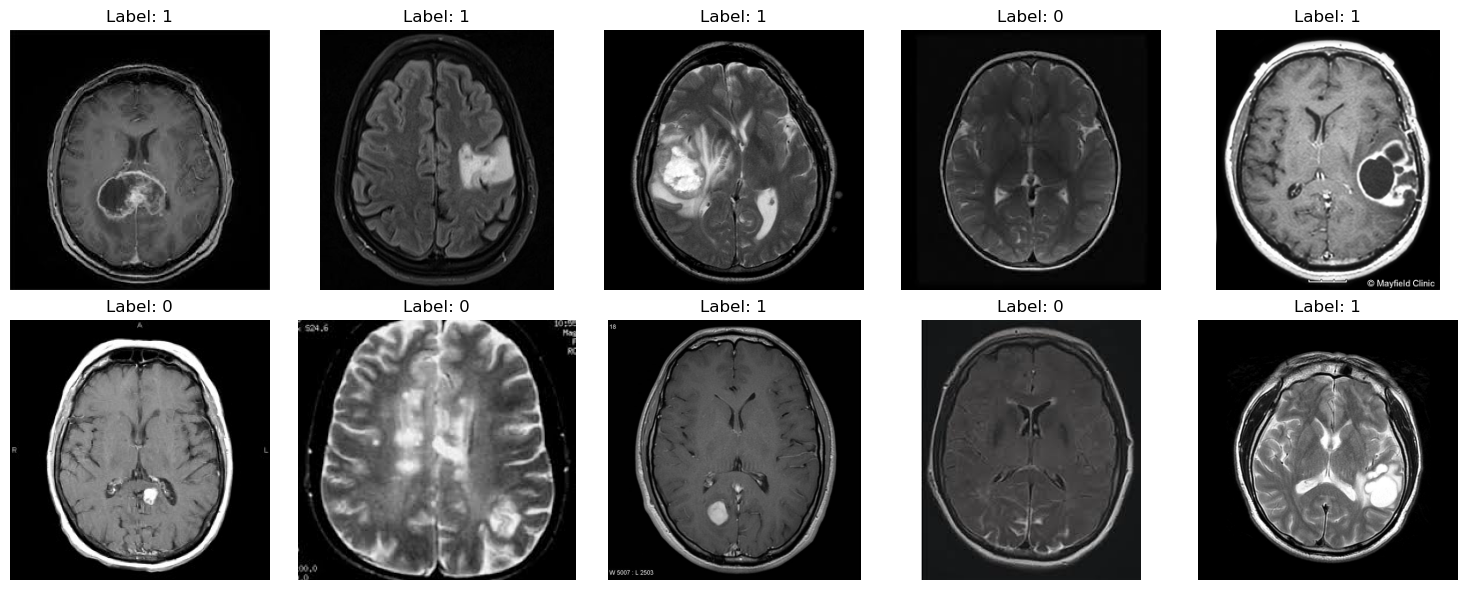

In [10]:
if len(image_paths) > 0:
    # Charger les images
    images = [cv2.imread(image_path) for image_path in image_paths]
    # Utilisation de la fonction pour visualiser les images
    visualize_images(images, labels)
    

<h2 style="color:#3366cc;"> Normalisation des Images</h2>

<p><b>Ces opérations servent à charger et redimensionner les images, puis à les convertir en un tableau NumPy pour une utilisation ultérieure, par exemple, lors de l'entraînement d'un modèle d'apprentissage automatique.</b></p>

In [11]:
images = [cv2.imread(image_path) for image_path in image_paths]
images = [cv2.resize(image, (244, 244)) for image in images]
images = np.array(images) / 255.0
labels = np.array(labels)

<h2 style="color:#3366cc;">Visualisation des Images Après Normalisation</h2>

<p><b>Ce code vérifie si des images ont été chargées, puis utilise une fonction pour visualiser les images. Ensuite, il affiche les valeurs normalisées des pixels de la première image, s'il y en a. Si aucune image n'a été chargée, il affiche un message indiquant qu'aucune image n'a été chargée.</b></p>

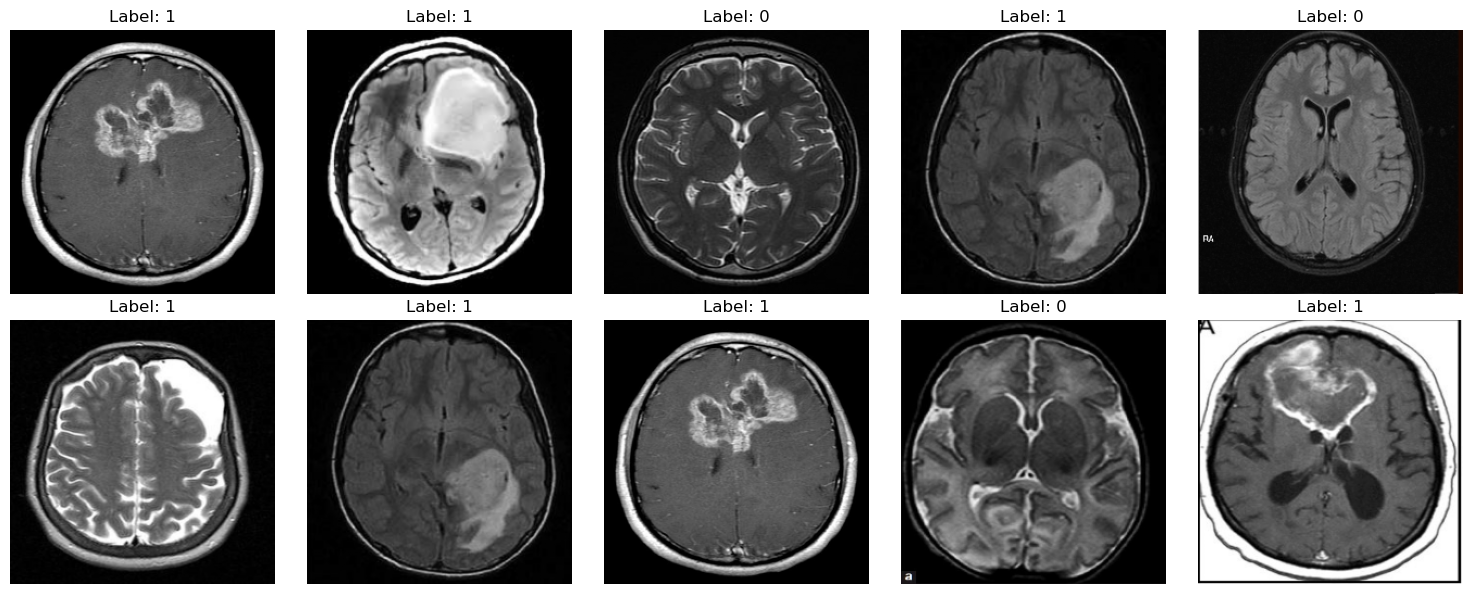

Affichage des pixels des images apres la normalisation:
[[[0.01176471 0.01176471 0.01176471]
  [0.01176471 0.01176471 0.01176471]
  [0.01176471 0.01176471 0.01176471]
  ...
  [0.00784314 0.00784314 0.00784314]
  [0.00784314 0.00784314 0.00784314]
  [0.00784314 0.00784314 0.00784314]]

 [[0.01176471 0.01176471 0.01176471]
  [0.01176471 0.01176471 0.01176471]
  [0.01176471 0.01176471 0.01176471]
  ...
  [0.00784314 0.00784314 0.00784314]
  [0.00784314 0.00784314 0.00784314]
  [0.00784314 0.00784314 0.00784314]]

 [[0.01176471 0.01176471 0.01176471]
  [0.01176471 0.01176471 0.01176471]
  [0.01176471 0.01176471 0.01176471]
  ...
  [0.00784314 0.00784314 0.00784314]
  [0.00784314 0.00784314 0.00784314]
  [0.00784314 0.00784314 0.00784314]]

 ...

 [[0.00784314 0.00784314 0.00784314]
  [0.00784314 0.00784314 0.00784314]
  [0.00784314 0.00784314 0.00784314]
  ...
  [0.00784314 0.00784314 0.00784314]
  [0.00784314 0.00784314 0.00784314]
  [0.01176471 0.01176471 0.01176471]]

 [[0.00784314 0.00

In [12]:

visualize_images(images, labels)
print("Affichage des pixels des images apres la normalisation:")
print(images[0])  # Affiche les valeurs des pixels de la première image
    

<h2 style="color:#3366cc;">Division des Données en Ensembles d'Entraînement et de Test</h2>

<p><b>Le code utilise la fonction `train_test_split` du module `sklearn.model_selection` pour diviser un ensemble d'images et de labels en ensembles distincts d'entraînement et de test. Les images sont redimensionnées à une taille spécifique. L'argument `test_size=0.10` indique que 10% des données seront utilisées comme ensemble de test, et `stratify=labels` garantit que la répartition des classes est maintenue dans les ensembles d'entraînement et de test. De plus, l'utilisation de `random_state=42` assure la reproductibilité de la division. Les résultats de cette opération sont quatre variables, à savoir `train_X`, `test_X`, `train_Y`, et `test_Y`, qui contiennent respectivement les données et les labels d'entraînement et de test. Ces ensembles sont prêts à être utilisés pour l'entraînement et l'évaluation d'un modèle d'apprentissage automatique.</b></p>

In [13]:
(train_X, test_X, train_Y, test_Y) = train_test_split(images, labels, test_size= 0.10, random_state= 42, stratify= labels)

In [14]:
print ("number of training examples = " + str(train_X.shape[0]))
print ("number of test examples = " + str(test_X.shape[0]))


number of training examples = 227
number of test examples = 26


<h2 style="color:#3366cc;">Encodage One-Hot des Étiquettes</h2>

<p><b>Ce code effectue un encodage one-hot des étiquettes (labels). Il convertit les variables de classe (train_Y et test_Y) en représentation one-hot, où chaque classe est représentée comme un vecteur binaire.</b></p>

In [15]:
# One-hot encode the labels
train_Y = to_categorical(train_Y, num_classes=2)
test_Y = to_categorical(test_Y, num_classes=2)

<h2 >Création du Modèle sans Utilisation de Régularisation</h2>

<h2 style="color:#3366cc;">Création du Modèle VGG16</h2>

<p><b>Ce code crée un modèle de base en utilisant l'architecture VGG16 pré-entraînée sur ImageNet. Voici une description brève de chaque ligne :

1) base_model = VGG16(weights='imagenet', input_tensor=Input(shape=(244, 244, 3)), include_top=False): Il charge le modèle VGG16 pré-entraîné sur le jeu de données ImageNet sans inclure les couches fully connected (include_top=False). Il spécifie également la forme de l'entrée avec input_tensor=Input(shape=(244, 244, 3)).

2) base_input = base_model.input: Il récupère la couche d'entrée du modèle VGG16.

3) base_output = base_model.output: Il récupère la sortie (features) de la dernière couche du modèle VGG16.

4) base_output = AveragePooling2D(pool_size=(4, 4))(base_output): Il applique une couche de pooling moyenne pour réduire les dimensions spatiales.

5) base_output = Flatten(name="flatten")(base_output): Il aplati les données en un vecteur 1D.

6) base_output = Dense(64, activation="relu")(base_output): Il ajoute une couche dense (fully connected) avec une fonction d'activation ReLU.

7) base_output = Dense(2, activation="softmax")(base_output): Il ajoute une couche dense avec une fonction d'activation softmax pour la classification binaire avec deux classes.</b></p>

In [16]:
base_model = VGG16(weights='imagenet', input_tensor=Input(shape=(244, 244, 3)), include_top=False)
base_input = base_model.input
base_output = base_model.output
base_output = AveragePooling2D(pool_size=(4, 4))(base_output)
base_output = Flatten(name="flatten")(base_output)
base_output = Dense(64, activation="relu")(base_output)
base_output = Dense(2, activation="softmax")(base_output)

<h2 style="color:#3366cc;">Fixation des Couches comme Non-Entraînables</h2>

<p><b>Ce code itère à travers les couches du modèle de base (base_model) et définit chaque couche comme non-entraînable. En fixant les couches comme non-entraînables, cela signifie que les poids de ces couches ne seront pas mis à jour lors de l'apprentissage du modèle ultérieur. </b></p>

In [17]:
for layer in base_model.layers:
    layer.trainable = False

<h2 style="color:#3366cc;">Création et Compilation du Nouveau Modèle</h2>

<p><b>Ce code crée un nouveau modèle (model) en spécifiant les entrées comme celles du modèle de base (base_input) et les sorties comme la sortie modifiée (base_output). Ensuite, il compile le modèle en utilisant l'optimiseur Adam avec un taux d'apprentissage de 1e-3, la perte binaire (binary_crossentropy), et la métrique d'évaluation de l'exactitude (accuracy).</b></p>

In [18]:
model_sans_augmentation = Model(inputs = base_input, outputs = base_output)
model_sans_augmentation.compile(optimizer= Adam(learning_rate= 1e-3), metrics= ['accuracy'], loss= 'binary_crossentropy')

<h2 style="color:#3366cc;">Architecture du Modèle</h2>

<p><b>Ce code affiche un résumé de l'architecture du modèle, montrant les différentes couches, le nombre de paramètres, et la structure globale du réseau neuronal. Cela permet d'avoir un aperçu des différentes parties du modèle et de vérifier s'il est conforme à ce qui était prévu.</b></p>

In [20]:
# Voyons l'architecture de notre modèle:
model_sans_augmentation.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 244, 244, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 244, 244, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 244, 244, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 122, 122, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 122, 122, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 122, 122, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 61, 61, 128)       0     

<p><b>Le modèle est basé sur l'architecture VGG16 pré-entraînée sur ImageNet. Il comprend plusieurs couches convolutionnelles (Conv2D) suivies de couches de pooling (MaxPooling2D) pour extraire des caractéristiques de l'image. Les dernières couches du modèle comprennent une couche d'aplanissement (Flatten) suivie de deux couches entièrement connectées (Dense). La dernière couche utilise une fonction d'activation softmax avec 2 neurones pour la classification binaire. Le modèle a un total de 14 747 650 paramètres, dont 32 962 sont entraînables. Les autres paramètres proviennent des couches convolutionnelles pré-entraînées qui sont figées (non entraînables). Ces informations montrent la complexité et la structure du modèle, ainsi que le nombre de paramètres qu'il apprend lors de l'entraînement.</b></p>

<h2 style="color:#3366cc;">Paramètres d'Entraînement</h2>

<p><b>Ces lignes de code définissent des paramètres importants pour l'entraînement du modèle, tels que la taille du lot (batch_size), le nombre d'étapes d'entraînement (train_steps) et le nombre d'étapes de validation (validation_steps). De plus, le nombre d'époques (epochs) est également spécifié pour déterminer combien de fois l'algorithme va traverser l'ensemble de données complet lors de l'entraînement.</b></p>

In [21]:
batch_size = 10
train_steps = len(train_X) // batch_size
validation_steps = len(test_X) // batch_size
epochs = 10

<h2 style="color:#3366cc;">Entraînement du Modèle</h2>

<p><b>Ces lignes de code lancent le processus d'entraînement du modèle. Le modèle est ajusté sur les données d'entraînement (train_X, train_Y) et sa performance est évaluée sur les données de validation (test_X, test_Y) pendant plusieurs époques, avec un certain batch_size. Les résultats de l'entraînement sont stockés dans l'objet history pour une analyse ultérieure.</b></p>

In [22]:
history_ = model_sans_augmentation.fit(
    train_X, train_Y,
    validation_data=(test_X, test_Y),
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/10


23/23 [==============================] - 134s 6s/step - loss: 0.6592 - accuracy: 0.5815 - val_loss: 0.6400 - val_accuracy: 0.6154
Epoch 2/10
23/23 [==============================] - 141s 6s/step - loss: 0.6072 - accuracy: 0.6432 - val_loss: 0.5940 - val_accuracy: 0.6154
Epoch 3/10
23/23 [==============================] - 143s 6s/step - loss: 0.5720 - accuracy: 0.7445 - val_loss: 0.5589 - val_accuracy: 0.7308
Epoch 4/10
23/23 [==============================] - 139s 6s/step - loss: 0.5315 - accuracy: 0.7577 - val_loss: 0.5308 - val_accuracy: 0.8846
Epoch 5/10
23/23 [==============================] - 134s 6s/step - loss: 0.4993 - accuracy: 0.8194 - val_loss: 0.4947 - val_accuracy: 0.8077
Epoch 6/10
23/23 [==============================] - 145s 6s/step - loss: 0.4809 - accuracy: 0.8238 - val_loss: 0.4655 - val_accuracy: 0.8846
Epoch 7/10
23/23 [==============================] - 141s 6s/step - loss: 0.4518 - accuracy: 0.8062 - val_loss: 0.4394 - val_accuracy: 0.8462
Epoch 8/10


<h2 style="color:#3366cc;">Évaluation du Modèle sur l'Ensemble de Test</h2>

<p><b>Cette ligne de code utilise le modèle entraîné pour effectuer des prédictions sur l'ensemble de données de test (test_X). </b></p>

In [23]:
 model_sans_augmentation.predict(test_X)

1/1 [==============================] - 14s 14s/step


array([[0.02248602, 0.977514  ],
       [0.00863458, 0.99136543],
       [0.9721115 , 0.02788849],
       [0.09120589, 0.90879416],
       [0.9648792 , 0.03512079],
       [0.6010594 , 0.39894062],
       [0.15222801, 0.847772  ],
       [0.79093146, 0.20906857],
       [0.06089881, 0.9391012 ],
       [0.06069389, 0.9393061 ],
       [0.09671216, 0.9032878 ],
       [0.60396415, 0.39603582],
       [0.9113435 , 0.08865645],
       [0.09817262, 0.9018274 ],
       [0.09649315, 0.9035069 ],
       [0.5478251 , 0.4521749 ],
       [0.39548263, 0.60451734],
       [0.90271217, 0.09728788],
       [0.51320124, 0.48679873],
       [0.01116049, 0.98883945],
       [0.9893351 , 0.01066486],
       [0.09120589, 0.90879416],
       [0.940958  , 0.05904201],
       [0.8319269 , 0.16807318],
       [0.95031327, 0.04968679],
       [0.5402271 , 0.45977288]], dtype=float32)

<h2 style="color:#3366cc;">Évaluation de la Performance</h2>

<p><b>Ce bloc de code effectue des prédictions sur l'ensemble de test (test_X) à l'aide du modèle, puis utilise ces prédictions pour générer un rapport de classification (classification_report) et une matrice de confusion (confusion_matrix). Ces informations permettent d'évaluer la performance du modèle sur l'ensemble de test en comparant les prédictions aux véritables étiquettes de classe. Le rapport de classification fournit des métriques telles que la précision, le rappel et le score F1 pour chaque classe, tandis que la matrice de confusion résume les résultats de la classification en comparant les prédictions positives et négatives avec les classes réelles.</b></p>

In [27]:
predictions = model_sans_augmentation.predict(test_X, batch_size=batch_size)
predictions = np.argmax(predictions, axis=1)
actuals = np.argmax(test_Y, axis=1)
print(classification_report(actuals, predictions))  # Ajout de la parenthèse manquante
cm = confusion_matrix(actuals, predictions)
print(cm)

3/3 [==============================] - 13s 4s/step
              precision    recall  f1-score   support

           0       0.64      0.90      0.75        10
           1       0.92      0.69      0.79        16

    accuracy                           0.77        26
   macro avg       0.78      0.79      0.77        26
weighted avg       0.81      0.77      0.77        26

[[ 9  1]
 [ 5 11]]


<p><b> Ce fragment de code calcule la précision globale du modèle en utilisant la matrice de confusion (cm). Il prend la somme des éléments diagonaux de la matrice de confusion (cm[0, 0] pour la classe 0 et cm[1, 1] pour la classe 1), qui représente le nombre total de prédictions correctes, puis divise par le nombre total d'échantillons pour obtenir la précision globale du modèle. La précision globale est ensuite affichée avec une précision de quatre chiffres après la virgule.
 </b></p>

In [28]:
total = sum(sum(cm))
accuracy = (cm[0, 0] + cm[1, 1]) / total
print("La précision globale de notre modèle est de: {:.4f}".format(accuracy))

La précision globale de notre modèle est de: 0.7692


<p><b>Le résultat que nous avons obtenu est une précision globale de 77%.</b></p>

<h2 style="color:#3366cc;">Courbes d'Apprentissage</h2>

<p><b>  Ces graphiques représentent les courbes d'apprentissage du modèle au fil des époques. Le premier graphique affiche les précisions d'entraînement (Train Accuracy) et de validation (Validation Accuracy) au cours des différentes époques. Le deuxième graphique montre les pertes d'entraînement (Train Loss) et de validation (Validation Loss) au fil des époques.</b></p>

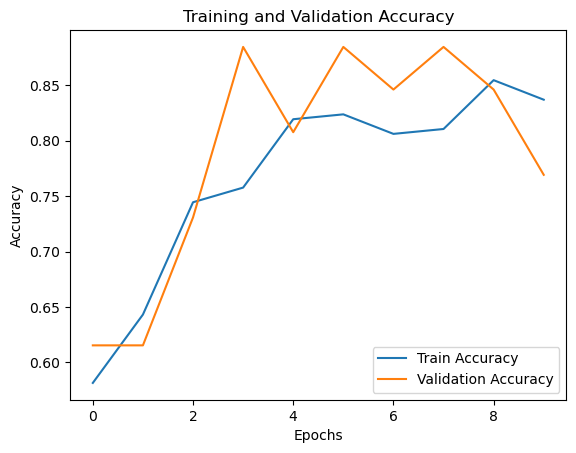

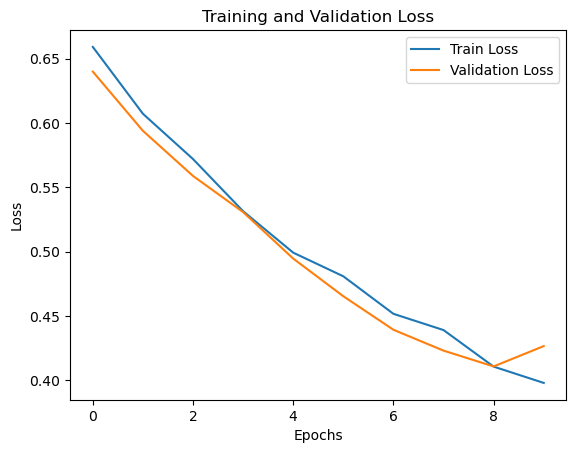

In [31]:
# Courbes d'apprentissage
plt.plot(history_.history['accuracy'], label='Train Accuracy')
plt.plot(history_.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_.history['loss'], label='Train Loss')
plt.plot(history_.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

<h2 style="color:#3366cc;">Précision sur l'Ensemble d'Entraînement et de Validation</h2>

<p><b>Ce code évalue le modèle sur l'ensemble d'entraînement (train_X, train_Y) et l'ensemble de validation (test_X, test_Y) pour calculer la perte et la précision. Ensuite, il affiche la précision du modèle sur l'ensemble d'entraînement et l'ensemble de validation. La précision est exprimée en pourcentage, fournissant une mesure de la performance du modèle sur les données d'entraînement et de validation.</b></p>

In [33]:
train_loss, train_accuracy = model_sans_augmentation.evaluate(train_X, train_Y, verbose=0)
val_loss, val_accuracy = model_sans_augmentation.evaluate(test_X, test_Y, verbose=0)

print(f'Train Accuracy: {train_accuracy * 100:.2f}%')  # Utilisation de train_accuracy au lieu de loss
print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')

Train Accuracy: 84.14%
Validation Accuracy: 76.92%


<p><b>Le modèle présente une précision de 84.14% sur l'ensemble d'entraînement et de 76.92% sur l'ensemble de validation.</b></p>

<h2 style="color:#3366cc;">Détection de Surajustement</h2>

<p><b>Ces instructions conditionnelles permettent d'évaluer la présence de surajustement (overfitting) en comparant les précisions du modèle sur l'ensemble d'entraînement et sur l'ensemble de validation. Voici une explication simplifiée :

- Si la précision sur l'ensemble d'entraînement est égale à la précision sur l'ensemble de validation, cela suggère qu'il n'y a pas de surajustement, et les performances sont similaires sur les deux ensembles.

- Si la précision sur l'ensemble d'entraînement est supérieure à la précision sur l'ensemble de validation, cela indique un surajustement. Le modèle performe mieux sur les données qu'il a vu pendant l'entraînement, mais il pourrait ne pas généraliser aussi bien sur de nouvelles données (ensemble de validation).

- Si la précision sur l'ensemble de validation est supérieure à la précision sur l'ensemble d'entraînement, cela peut suggérer une bonne généralisation du modèle sur de nouvelles données.</b></p>

In [34]:
if train_accuracy == val_accuracy:
    print("Pas de surajustement. Les performances sur l'ensemble d'entraînement et de validation sont similaires.")
elif train_accuracy > val_accuracy:
    print("Surajustement détecté. Le modèle performe mieux sur l'ensemble d'entraînement que sur l'ensemble de validation.")
else:
    print("Pas de surajustement détecté. Le modèle performe mieux sur l'ensemble de validation que sur l'ensemble d'entraînement.")

Surajustement détecté. Le modèle performe mieux sur l'ensemble d'entraînement que sur l'ensemble de validation.


<h2 style="color:#3366cc;">Augmentation de datset </h2>

**Description des données :** <br>
Le jeu de données est composé d'images IRM cérébrales, caractérisé par une prédominance de 61% d'images tumorales (155) par rapport à une minorité de 39% d'images non tumorales (98). Ce déséquilibre notable dans la distribution des classes a conduit à des problèmes de surajustement lors de la modélisation.

Pour atténuer cette situation liée à la petite taille de l'ensemble de données, nous avons mis en œuvre l'augmentation de données afin de créer des images supplémentaires. Cette approche apporte de la variabilité, favorisant ainsi une meilleure généralisation du modèle, en particulier dans le contexte du déséquilibre entre les classes tumorales et non tumorales. L'objectif ultime est d'améliorer la performance du modèle sur de nouvelles données tout en évitant la suradaptation aux limitations des données d'entraînement. Cette démarche a permis d'optimiser la représentation des deux classes au sein de l'ensemble d'entraînement.







La fonction renvoie une chaîne de caractères qui représente le temps écoulé au format "heures:minutes:secondes". Cette fonction est pratique pour afficher la durée d'exécution lors de l'accomplissement d'une tâche, telle que la formation d'un modèle, où le temps est généralement mesuré en secondes.

In [7]:
def format_duree(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{round(s, 1)}"

        

<h2 style="color:#3366cc;">La fonction `augment_data` prend trois paramètres </h2> :

 <p><b> file_dir:</b> Le chemin du répertoire contenant les images d'origine que vous souhaitez augmenter.</p>

 <p><b> n_generated_samples :</b></p> Le nombre d'échantillons augmentés que vous souhaitez générer à partir de chaque image d'origine.

<p><b> save_to_dir save_to_dir:</b> Le répertoire dans lequel les échantillons augmentés seront sauvegardés.</p>


<b> Explication de la fonction :</b></p>

- Un objet 'ImageDataGenerator' est créé avec diverses transformations spécifiées telles que la rotation, le décalage horizontal et vertical, le cisaillement, la modification de la luminosité, et la possibilité de basculer l'image horizontalement et verticalement.<br><br>

- La fonction parcourt chaque fichier dans le répertoire spécifié par 'file_dir'.<br><br>

- Pour chaque image, elle charge l'image à l'aide de OpenCV, la remodèle, puis génère plusieurs images augmentées en utilisant la méthode 'flow' de l'objet 'ImageDataGenerator'. Ces images augmentées sont sauvegardées dans le répertoire spécifié par 'save_to_dir'.<br><br>

- Le préfixe du nom des fichiers sauvegardés pour les échantillons générés est défini comme 'aug_' suivi du nom d'origine du fichier (à l'exclusion de l'extension).<br><br>

- La génération d'échantillons s'arrête après avoir créé le nombre spécifié de 'n_generated_samples' images augmentées pour chaque image d'origine.<br><br>



In [10]:
def augment_data(file_dir, n_generated_samples, save_to_dir):

    data_gen = ImageDataGenerator(rotation_range=10, 
                                  width_shift_range=0.1, 
                                  height_shift_range=0.1, 
                                  shear_range=0.1, 
                                  brightness_range=(0.3, 1.0),
                                  horizontal_flip=True, 
                                  vertical_flip=True, 
                                  fill_mode='nearest'
                                 )

    
    for filename in listdir(file_dir):
        # load the image
        image = cv2.imread(file_dir + '\\' + filename)
        # reshape the image
        image = image.reshape((1,)+image.shape)
        # prefix of the names for the generated sampels.
        save_prefix = 'aug_' + filename[:-4]
        # generate 'n_generated_samples' sample images
        i=0
        for batch in data_gen.flow(x=image, batch_size=1, save_to_dir=save_to_dir, 
                                           save_prefix=save_prefix, save_format='jpg'):
            i += 1
            if i > n_generated_samples:
                break

N'oublions pas que 61% des données (155 images) sont tumorales et 39% des données (98 images) sont non tumorales. Afin d'équilibrer les données, nous pouvons générer 9 nouvelles images pour chaque image appartenant à la classe 'non tumorale' et 6 images pour chaque image appartenant à la classe 'tumorale'.

 ce script effectue l'augmentation de données pour les images tumorales et non tumorales, enregistre les résultats dans des répertoires spécifiques, et mesure le temps total d'exécution.

L'affichage du temps écoulé est essentiel pour plusieurs raisons :


Évaluation des performances : Cela permet de mesurer l'efficacité du processus d'augmentation de données. Une exécution plus rapide peut indiquer une amélioration des performances ou une optimisation du code.

Diagnostic des problèmes : Si le temps d'exécution est anormalement long, cela peut indiquer des problèmes potentiels, tels que des erreurs dans le code, des limitations matérielles ou des inefficacités dans l'algorithme d'augmentation de données.

In [13]:
start_time = time.time()
yes_path ='brain_tumor_dataset/yes/'
no_path = 'brain_tumor_dataset/no/'

augmented_data_path = 'augmentation data/'
# augment data for the examples with label equal to 'yes' representing tumurous examples
augment_data(file_dir=yes_path, n_generated_samples=6, save_to_dir=augmented_data_path+'yes')
# augment data for the examples with label equal to 'no' representing non-tumurous examples
augment_data(file_dir=no_path, n_generated_samples=9, save_to_dir=augmented_data_path+'no')
end_time = time.time()
execution_time = (end_time - start_time)
print(f"Temps écoulé: {format_duree(execution_time)}")

Temps écoulé: 0:3:19.3


cette fonction  affiche un résumé comprenant le nombre total d'exemples, le pourcentage d'exemples positifs avec leur nombre correspondant, et le pourcentage d'exemples négatifs avec leur nombre correspondant.

In [3]:
def data_summary(dataset_path):
    
    yes_path = dataset_path+'yes'
    no_path = dataset_path+'no'
        
    # number of files (images) that are in the the folder named 'yes' that represent tumorous (positive) examples
    m_pos = len(listdir(yes_path))
    # number of files (images) that are in the the folder named 'no' that represent non-tumorous (negative) examples
    m_neg = len(listdir(no_path))
    # number of all examples
    m = (m_pos+m_neg)
    
    pos_prec = (m_pos* 100.0)/ m
    neg_prec = (m_neg* 100.0)/ m
    
    print(f"Number of examples: {m}")
    print(f"Percentage of positive examples: {pos_prec}%, number of pos examples: {m_pos}") 
    print(f"Percentage of negative examples: {neg_prec}%, number of neg examples: {m_neg}") 

In [5]:
augmented_data_path = 'augmentation data/'
data_summary(augmented_data_path)

Number of examples: 2065
Percentage of positive examples: 52.54237288135593%, number of pos examples: 1085
Percentage of negative examples: 47.45762711864407%, number of neg examples: 980


<h1 style="color:#3366cc;">Détection de tumeur cérébrale à l'aide d'un réseau neuronal convolutionnel </h1> 

## Data Preparation & Preprocessing

Cette fonction, nommée `crop_brain_contour`, est conçue pour extraire le contour d'un cerveau dans une image médicale. Elle prend en entrée une image couleur, convertit celle-ci en niveaux de gris, puis applique un flou gaussien pour réduire le bruit. Ensuite, elle effectue un seuillage pour obtenir une image binaire, suivie d'une série d'érosions et de dilatations pour éliminer les petites régions de bruit. Les contours de l'image seuillée sont ensuite trouvés, et le plus grand contour (supposément le contour du cerveau) est identifié. Les points extrêmes (gauche, droite, haut, bas) de ce contour sont utilisés pour découper une nouvelle image centrée sur le cerveau. L'option plot permet d'afficher graphiquement l'image originale et l'image recadrée côte à côte à des fins de visualisation. Enfin, la nouvelle image du cerveau est renvoyée. Cette fonction est utile dans le domaine de l'analyse d'images médicales pour isoler spécifiquement le cerveau en vue d'analyses ultérieures.

In [35]:
import cv2
from matplotlib import pyplot as plt

def crop_brain_contour(image, plot=False):
    # Convert the image to grayscale, and blur it slightly
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Threshold the image, then perform a series of erosions +
    # dilations to remove any small regions of noise
    _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Find contours in thresholded image
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Find the largest contour
    c = max(contours, key=cv2.contourArea)

    # Find the extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # Crop new image out of the original image using the four extreme points (left, right, top, bottom)
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    if plot:
        plt.figure()
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.tick_params(axis='both', which='both', top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        plt.title('Original Image')

        plt.subplot(1, 2, 2)
        plt.imshow(new_image)
        plt.tick_params(axis='both', which='both', top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        plt.title('Cropped Image')

        plt.show()

    return new_image



Afin de mieux comprendre son fonctionnement, prenons une image du jeu de données et appliquons cette fonction de recadrage pour voir le résultat :

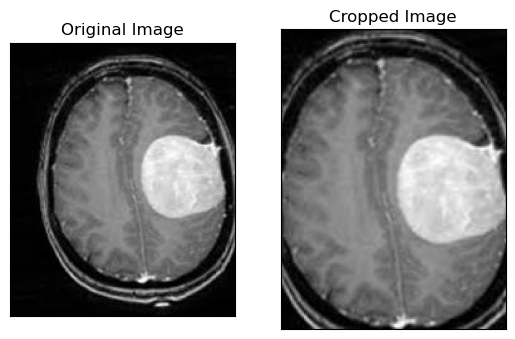

In [3]:
import os

image_path = 'augmentation data/yes/aug_1_0_0_276.jpg'

if os.path.exists(image_path):
    ex_img = cv2.imread(image_path)
    ex_new_img = crop_brain_contour(ex_img, True)
else:
    print(f"Le fichier {image_path} n'existe pas.")


### Load up the data:

La fonction suivante prend deux arguments. Le premier est une liste de chemins d'accès pour les dossiers 'yes' et 'no' contenant les données d'images, et le deuxième argument est la taille de l'image. Pour chaque image dans ces répertoires, la fonction effectue les étapes suivantes :
1. Lecture de l'image.
2. Recadrage de la partie de l'image représentant uniquement le cerveau.
3. Redimensionnement de l'image, car les images du jeu de données ont des tailles différentes (largeur, hauteur et nombre de canaux). Ainsi, nous voulons que toutes nos images aient la taille (240, 240, 3) pour les utiliser en entrée du réseau neuronal.
4. Application de la normalisation pour que les valeurs des pixels soient mises à l'échelle dans la plage de 0 à 1.
5. Ajout de l'image à <i>X</i> et de son libellé à <i>y</i>.<br>

Ensuite, la fonction mélange <i>X</i> et <i>y</i>, car les données sont ordonnées (c'est-à-dire que les tableaux contiennent une première partie appartenant à une classe et une deuxième partie appartenant à l'autre classe, et nous ne voulons pas cela).<br>
Enfin, elle retourne <i>X</i> et <i>y</i>.

In [36]:
def load_data(dir_list, image_size):
   

    # load all images in a directory
    X = []
    y = []
    image_width, image_height = image_size
    
    for directory in dir_list:
        for filename in listdir(directory):
            # load the image
            image = cv2.imread(directory + '\\' + filename)
            # crop the brain and ignore the unnecessary rest part of the image
            image = crop_brain_contour(image, plot=False)
            # resize image
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation=cv2.INTER_CUBIC)
            # normalize values
            image = image / 255.
            # convert image to numpy array and append it to X
            X.append(image)
            # append a value of 1 to the target array if the image
            # is in the folder named 'yes', otherwise append 0.
            if directory[-3:] == 'yes':
                y.append([1])
            else:
                y.append([0])
                
    X = np.array(X)
    y = np.array(y)
    
    # Shuffle the data
    X, y = shuffle(X, y)
    
    print(f'Number of examples is: {len(X)}')
    print(f'X shape is: {X.shape}')
    print(f'y shape is: {y.shape}')
    
    return X, y

Chargez les données que nous avons augmentées précédemment dans le notebook sur l'Augmentation de Données.<br>
**Remarque :** le répertoire des données augmentées contient non seulement les nouvelles images générées, mais aussi les images originales.

In [5]:
augmented_path = 'augmentation data/'

# augmented data (yes and no) contains both the original and the new generated examples
augmented_yes = augmented_path + 'yes' 
augmented_no = augmented_path + 'no'

IMG_WIDTH, IMG_HEIGHT = (240, 240)

X, y = load_data([augmented_yes, augmented_no], (IMG_WIDTH, IMG_HEIGHT))

Number of examples is: 2065
X shape is: (2065, 240, 240, 3)
y shape is: (2065, 1)


Comme nous pouvons le voir, nous avons 2065 images. Chaque image a une forme de **(240, 240, 3) = (largeur_de_l'image, hauteur_de_l'image, nombre_de_canaux)**.

### Afficher des exemples d'images :

In [17]:
def plot_sample_images(X, y, n=50):
   
    
    for label in [0,1]:
        # grab the first n images with the corresponding y values equal to label
        images = X[np.argwhere(y == label)]
        n_images = images[:n]
        
        columns_n = 10
        rows_n = int(n/ columns_n)

        plt.figure(figsize=(20, 10))
        
        i = 1 # current plot        
        for image in n_images:
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image[0])
            
            # remove ticks
            plt.tick_params(axis='both', which='both', 
                            top=False, bottom=False, left=False, right=False,
                           labelbottom=False, labeltop=False, labelleft=False, labelright=False)
            
            i += 1
        
        label_to_str = lambda label: "Yes" if label == 1 else "No"
        plt.suptitle(f"Brain Tumor: {label_to_str(label)}")
        plt.show()

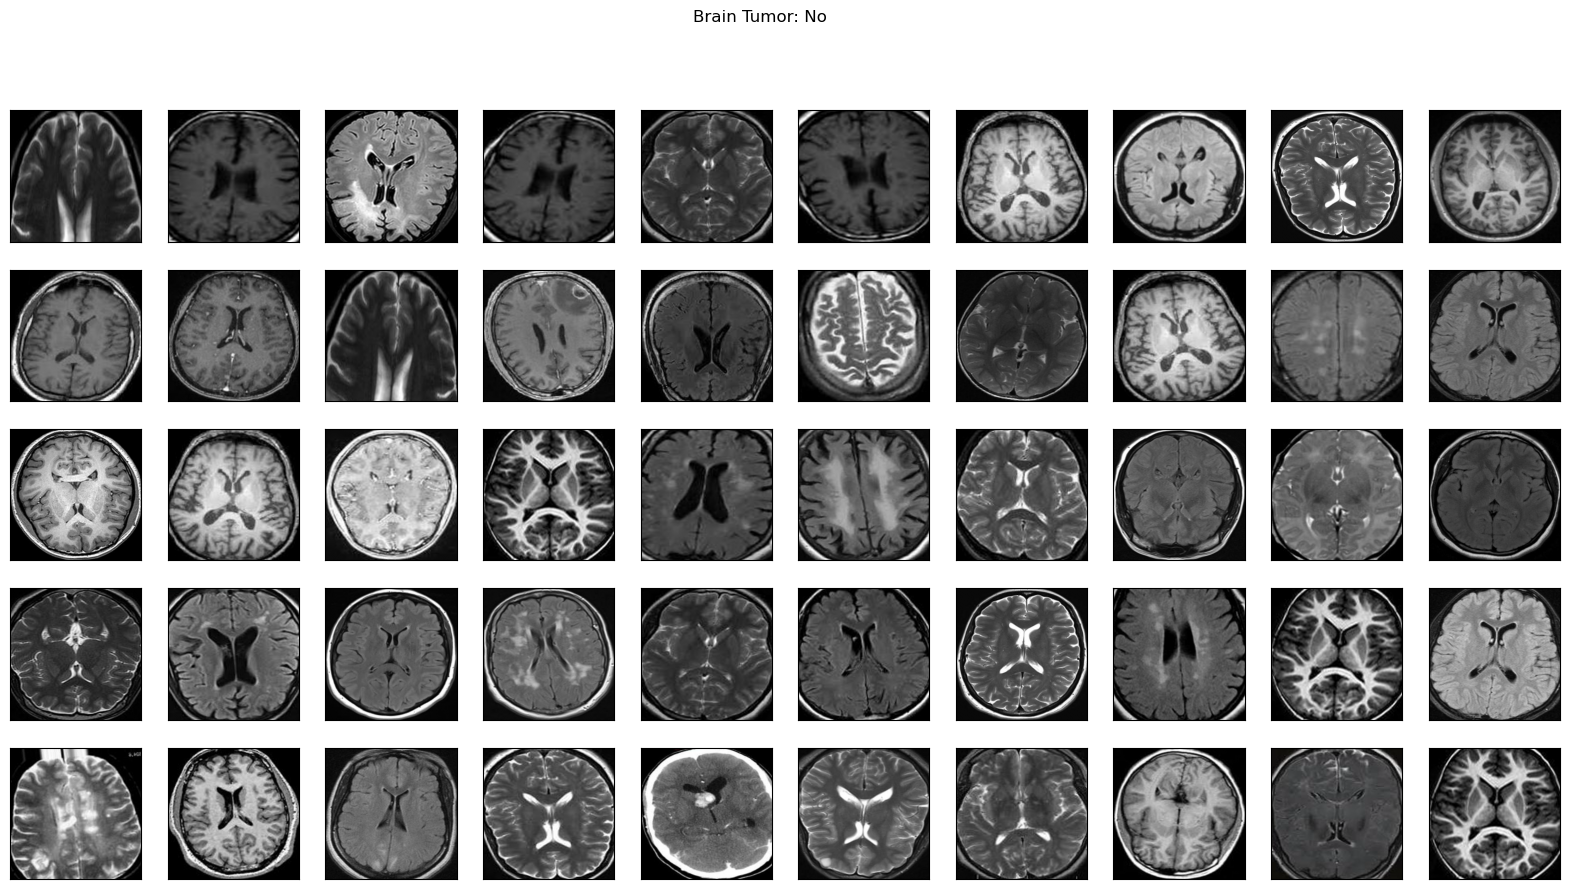

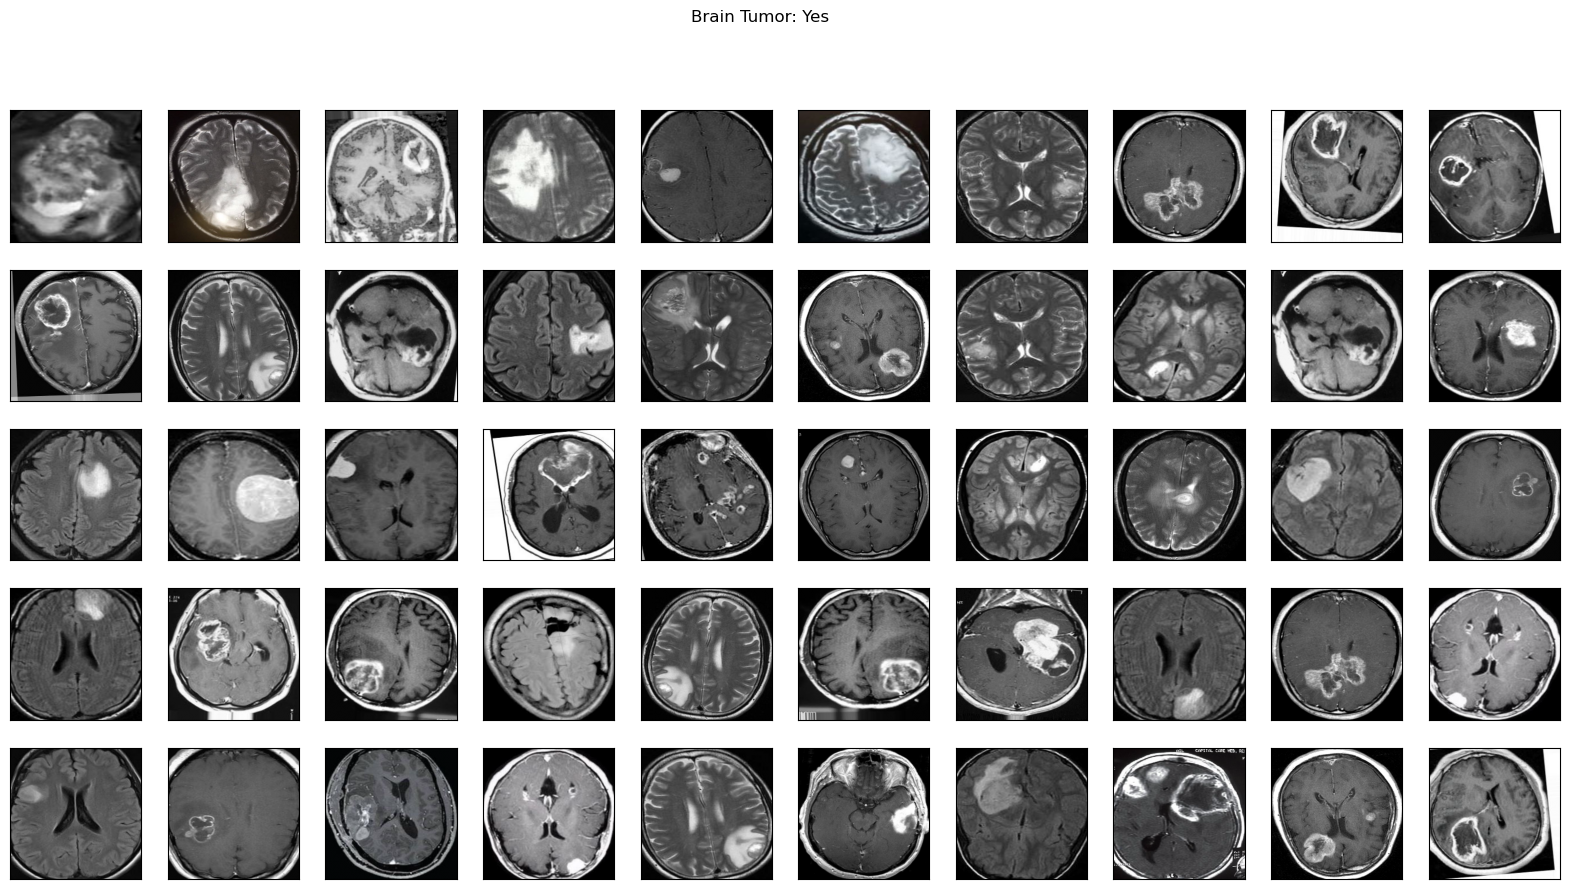

In [18]:
plot_sample_images(X, y)

### Diviser les données :
Divisez <i>X</i> et <i>y</i> en ensembles d'entraînement, de validation (développement) et de test.

In [6]:
def split_data(X, y, test_size=0.2):
   
    X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=test_size)
    X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5)
    
    return X_train, y_train, X_val, y_val, X_test, y_test

Utilisons la répartition suivante :
1. 70 % des données pour l'entraînement.
2. 15 % des données pour la validation.
3. 15 % des données pour les tests.

In [7]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y, test_size=0.3)

In [21]:
print ("number of training examples = " + str(X_train.shape[0]))
print ("number of development examples = " + str(X_val.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(y_train.shape))
print ("X_val (dev) shape: " + str(X_val.shape))
print ("Y_val (dev) shape: " + str(y_val.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(y_test.shape))

number of training examples = 1445
number of development examples = 310
number of test examples = 310
X_train shape: (1445, 240, 240, 3)
Y_train shape: (1445, 1)
X_val (dev) shape: (310, 240, 240, 3)
Y_val (dev) shape: (310, 1)
X_test shape: (310, 240, 240, 3)
Y_test shape: (310, 1)


In [8]:
def compute_f1_score(y_true, prob):
    # convert the vector of probabilities to a target vector
    y_pred = np.where(prob > 0.5, 1, 0)
    
    score = f1_score(y_true, y_pred)
    
    return score

# Construire le modèle

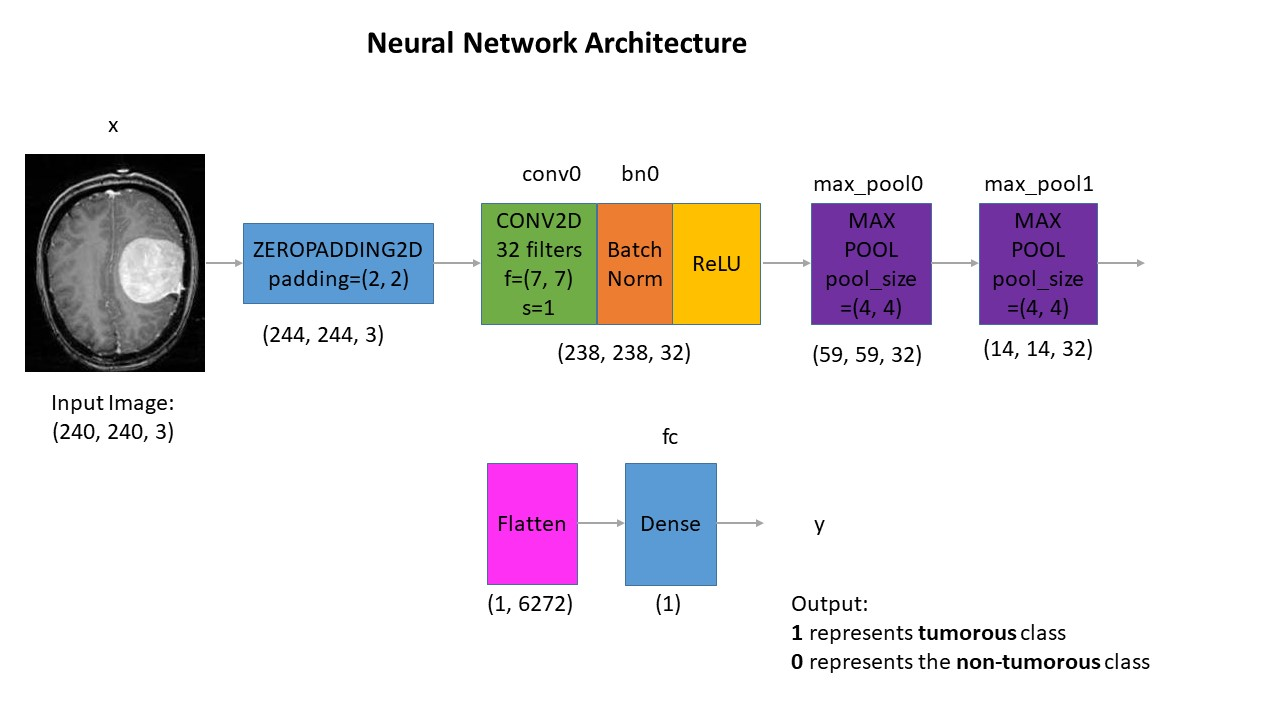

In [16]:
from IPython.display import Image

# Replace 'your_image_path.jpg' with the actual path of your image file
Image(filename='convnet_architecture.jpg')




La fonction `build_model` est destinée à créer un modèle de réseau de neurones convolutif (CNN) pour la détection d'images cérébrales. Voici une description des différentes étapes de construction du modèle :

1. **Couche d'Entrée :** La première étape consiste à définir la couche d'entrée du réseau, spécifiant la forme attendue des données d'entrée, qui sont généralement des images.

2. **Remplissage avec des Zéros :** Pour éviter la perte d'informations importantes lors de la convolution, la fonction ajoute une couche de remplissage avec des zéros autour des bords des images d'entrée.

3. **Bloc de Convolution :** Un bloc de convolution est utilisé pour extraire des caractéristiques importantes des images. Il comprend une couche de convolution avec 32 filtres de taille (7, 7), suivie de la normalisation par lots (Batch Normalization) pour stabiliser et accélérer l'apprentissage, et enfin, une activation ReLU (Rectified Linear Unit) pour introduire la non-linéarité.

4. **Couches de MaxPooling :** Deux couches de MaxPooling sont ajoutées pour réduire la dimension spatiale des caractéristiques extraites, en prenant la valeur maximale dans des fenêtres spécifiques.

5. **Couche de Mise à Plat :** La couche de mise à plat est utilisée pour transformer les données en une seule dimension, ce qui est nécessaire avant de passer à la couche entièrement connectée.

6. **Couche Entièrement Connectée :** Une couche entièrement connectée avec une seule sortie est ajoutée, utilisant une fonction d'activation sigmoïde. Cela permet au modèle de générer une sortie entre 0 et 1, ce qui est souvent utilisé pour les tâches de classification binaire.

7. **Création du Modèle :** Enfin, le modèle global est créé en spécifiant les couches d'entrée et de sortie, et il est nommé "BrainDetectionModel".

En résumé, la fonction `build_model` définit une architecture de réseau de neurones convolutif pour la détection d'images cérébrales, avec des couches de convolution, de normalisation, de max pooling, et une couche entièrement connectée pour la classification binaire.

In [9]:
def build_model(input_shape):
    # Define the input placeholder as a tensor with shape input_shape. 
    X_input = Input(input_shape) # shape=(?, 240, 240, 3)
    
    # Zero-Padding: pads the border of X_input with zeroes
    X = ZeroPadding2D((2, 2))(X_input) # shape=(?, 244, 244, 3)
    
    # CONV -> BN -> RELU Block applied to X
    X = Conv2D(32, (7, 7), strides = (1, 1), name = 'conv0')(X)
    X = BatchNormalization(axis = 3, name = 'bn0')(X)
    X = Activation('relu')(X) # shape=(?, 238, 238, 32)
    
    # MAXPOOL
    X = MaxPooling2D((4, 4), name='max_pool0')(X) # shape=(?, 59, 59, 32) 
    
    # MAXPOOL
    X = MaxPooling2D((4, 4), name='max_pool1')(X) # shape=(?, 14, 14, 32)
    
    # FLATTEN X 
    X = Flatten()(X) # shape=(?, 6272)
    # FULLYCONNECTED
    X = Dense(1, activation='sigmoid', name='fc')(X) # shape=(?, 1)
    
    # Create model. This creates your Keras model instance, you'll use this instance to train/test the model.
    model = Model(inputs = X_input, outputs = X, name='BrainDetectionModel')
    
    return model

In [10]:
IMG_SHAPE = (IMG_WIDTH, IMG_HEIGHT, 3)

In [11]:
model = build_model(IMG_SHAPE)

In [13]:
model.summary()

Model: "BrainDetectionModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 240, 240, 3)]     0         
                                                                 
 zero_padding2d (ZeroPaddin  (None, 244, 244, 3)       0         
 g2D)                                                            
                                                                 
 conv0 (Conv2D)              (None, 238, 238, 32)      4736      
                                                                 
 bn0 (BatchNormalization)    (None, 238, 238, 32)      128       
                                                                 
 activation (Activation)     (None, 238, 238, 32)      0         
                                                                 
 max_pool0 (MaxPooling2D)    (None, 59, 59, 32)        0         
                                               


1. **Model Summary :**
   - **"BrainDetectionModel" :** C'est le nom donné au modèle.

2. **Layers (Couches) :**
   - **input_1 (InputLayer) :** C'est la couche d'entrée du modèle, spécifiant la forme des données d'entrée (240, 240, 3), où 240 et 240 sont les dimensions spatiales de l'image, et 3 représente les canaux de couleur (Rouge, Vert, Bleu).

   - **zero_padding2d (ZeroPadding2D) :** Cette couche ajoute un rembourrage de zéros autour des bords des images d'entrée, modifiant ainsi la forme des données d'entrée.

   - **conv0 (Conv2D) :** Cette couche de convolution applique 32 filtres de taille (7, 7) à l'image d'entrée, générant une sortie avec des dimensions (238, 238, 32). Le nombre de paramètres pour cette couche est 4736.

   - **bn0 (BatchNormalization) :** Cette couche normalise les activations de la couche précédente, contribuant à la stabilité et à la convergence plus rapide du modèle. Elle a 128 paramètres.

   - **activation (Activation) :** Cette couche applique la fonction d'activation ReLU à la sortie de la couche précédente.

   - **max_pool0 (MaxPooling2D) :** C'est une couche de max pooling avec une fenêtre de (4, 4), réduisant les dimensions spatiales de la sortie à (59, 59, 32).

   - **max_pool1 (MaxPooling2D) :** Une deuxième couche de max pooling est appliquée, réduisant davantage les dimensions spatiales à (14, 14, 32).

   - **flatten (Flatten) :** Cette couche transforme les données en une seule dimension, préparant ainsi les données pour la couche entièrement connectée. La sortie est un vecteur de forme (6272).

   - **fc (Dense) :** C'est la couche entièrement connectée avec une seule sortie (unité), utilisant la fonction d'activation sigmoïde. Elle a 6273 paramètres.

3. **Total params (Nombre total de paramètres) :**
   - Il s'agit du nombre total de paramètres dans le modèle, comprenant les poids des filtres, les biais et les paramètres de normalisation. Dans ce cas, le modèle a un total de 11,137 paramètres.

4. **Trainable params (Nombre de paramètres entraînables) :**
   - C'est le nombre de paramètres qui seront ajustés pendant l'entraînement du modèle. Ces paramètres incluent les poids des filtres et les biais. Dans ce cas, il y a 11,073 paramètres entraînables.

5. **Non-trainable params (Nombre de paramètres non entraînables) :**
   - Il s'agit du nombre de paramètres qui ne seront pas ajustés pendant l'entraînement. Dans ce modèle, cela inclut les paramètres de la couche d'entrée (rembourrage de zéros). Il y a 64 paramètres non entraînables.

En résumé, cette description fournit des détails sur la structure du modèle, les différentes couches utilisées, le nombre total de paramètres, et ceux qui sont entraînables et non entraînables.

In [14]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

L'utilisation de TensorBoard est utile pour visualiser des métriques telles que les courbes d'apprentissage, les distributions de poids, les activations de couches, etc. pendant l'entraînement du modèle. Vous pouvez exécuter TensorBoard dans votre terminal en pointant vers le répertoire de fichiers journaux spécifié ('logs' dans ce cas), ce qui vous permet de surveiller et d'analyser l'évolution de votre modèle au fil du temps.

En résumé, ces lignes de code créent un nom de fichier de journal unique basé sur le timestamp actuel et configurent TensorBoard pour enregistrer les fichiers journaux dans un répertoire spécifique pour l'analyse et la visualisation ultérieures.







In [15]:

log_file_name = f'brain_tumor_detection_cnn_{int(time.time())}'
tensorboard = TensorBoard(log_dir=f'logs/{log_file_name}')


ce code configure un point de contrôle pendant l'entraînement du modèle, sauvegardant le modèle à chaque époque uniquement si la précision de validation (development) à cette époque est meilleure que celle enregistrée lors des époques précédentes. Cela permet de conserver uniquement le meilleur modèle en termes de précision de validation.

In [16]:
# checkpoint
# nom de fichier unique qui inclura l'époque et la précision de validation (development)
filepath = "cnn-parameters-improvement-{epoch:02d}-{val_accuracy:.2f}"

# sauvegarder le modèle avec la meilleure précision de validation (development) jusqu'à présent
checkpoint = ModelCheckpoint("models/{}.model".format(filepath), monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')


In [24]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=10, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {format_duree(execution_time)}")

Epoch 1/10


46/46 [==============================] - ETA: 0s - loss: 0.8691 - accuracy: 0.6028
Epoch 1: val_accuracy improved from -inf to 0.67097, saving model to models\cnn-parameters-improvement-01-0.67.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-01-0.67.model\assets


INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-01-0.67.model\assets


46/46 [==============================] - 89s 2s/step - loss: 0.8691 - accuracy: 0.6028 - val_loss: 0.6490 - val_accuracy: 0.6710
Epoch 2/10
46/46 [==============================] - ETA: 0s - loss: 0.5427 - accuracy: 0.7176
Epoch 2: val_accuracy did not improve from 0.67097
46/46 [==============================] - 65s 1s/step - loss: 0.5427 - accuracy: 0.7176 - val_loss: 0.6090 - val_accuracy: 0.6710
Epoch 3/10
46/46 [==============================] - ETA: 0s - loss: 0.4845 - accuracy: 0.7661
Epoch 3: val_accuracy improved from 0.67097 to 0.71613, saving model to models\cnn-parameters-improvement-03-0.72.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-03-0.72.model\assets


INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-03-0.72.model\assets


46/46 [==============================] - 63s 1s/step - loss: 0.4845 - accuracy: 0.7661 - val_loss: 0.5714 - val_accuracy: 0.7161
Epoch 4/10
46/46 [==============================] - ETA: 0s - loss: 0.3650 - accuracy: 0.8505
Epoch 4: val_accuracy improved from 0.71613 to 0.73548, saving model to models\cnn-parameters-improvement-04-0.74.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-04-0.74.model\assets


...

46/46 [==============================] - 82s 2s/step - loss: 0.3040 - accuracy: 0.8740 - val_loss: 0.5005 - val_accuracy: 0.7645
Epoch 6/10
46/46 [==============================] - ETA: 0s - loss: 0.2907 - accuracy: 0.8713
Epoch 6: val_accuracy did not improve from 0.76452
46/46 [==============================] - 72s 2s/step - loss: 0.2907 - accuracy: 0.8713 - val_loss: 0.6263 - val_accuracy: 0.6452
Epoch 7/10
46/46 [==============================] - ETA: 0s - loss: 0.2383 - accuracy: 0.9100
Epoch 7: val_accuracy did not improve from 0.76452
46/46 [==============================] - 74s 2s/step - loss: 0.2383 - accuracy: 0.9100 - val_loss: 0.8123 - val_accuracy: 0.5452
Epoch 8/10
46/46 [==============================] - ETA: 0s - loss: 0.3207 - accuracy: 0.8588
Epoch 8: val_accuracy improved from 0.76452 to 0.81613, saving model to models\cnn-parameters-improvement-08-0.82.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-08-0.82.model\assets


INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-08-0.82.model\assets


46/46 [==============================] - 73s 2s/step - loss: 0.3207 - accuracy: 0.8588 - val_loss: 0.4021 - val_accuracy: 0.8161
Epoch 9/10
46/46 [==============================] - ETA: 0s - loss: 0.2295 - accuracy: 0.9073
Epoch 9: val_accuracy did not improve from 0.81613
46/46 [==============================] - 76s 2s/step - loss: 0.2295 - accuracy: 0.9073 - val_loss: 0.4486 - val_accuracy: 0.7839
Epoch 10/10
46/46 [==============================] - ETA: 0s - loss: 0.1945 - accuracy: 0.9253
Epoch 10: val_accuracy improved from 0.81613 to 0.84839, saving model to models\cnn-parameters-improvement-10-0.85.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-10-0.85.model\assets


INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-10-0.85.model\assets


46/46 [==============================] - 71s 2s/step - loss: 0.1945 - accuracy: 0.9253 - val_loss: 0.3476 - val_accuracy: 0.8484
Elapsed time: 0:12:45.6


ce code mesure le temps écoulé pour l'entraînement du modèle, utilise la méthode fit pour entraîner le modèle pendant 10 époques, enregistre le temps de début et de fin, puis affiche la durée totale de l'entraînement.

In [33]:
history = model.history.history

In [34]:
for key in history.keys():
    print(key)

loss
accuracy
val_loss
val_accuracy


## Plot Loss & Accuracy

In [35]:
def plot_metrics(history):
    
    train_loss_aug = history['loss']
    val_loss_aug = history['val_loss']
    train_acc_aug = history['accuracy']
    val_acc_aug = history['val_accuracy']
    
    # Loss
    plt.figure()
    plt.plot(train_loss_aug, label='Training Loss')
    plt.plot(val_loss_aug, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()
    
    # Accuracy
    plt.figure()
    plt.plot(train_acc_aug, label='Training Accuracy')
    plt.plot(val_acc_aug, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

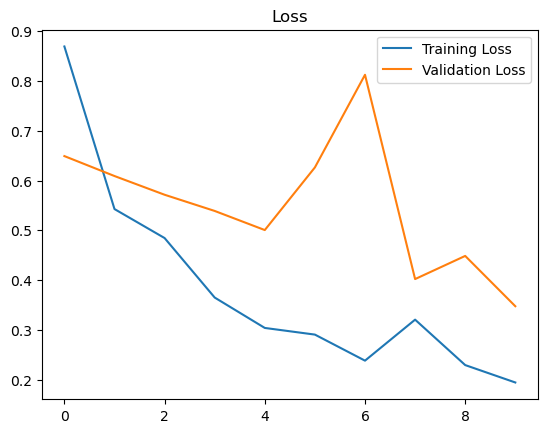

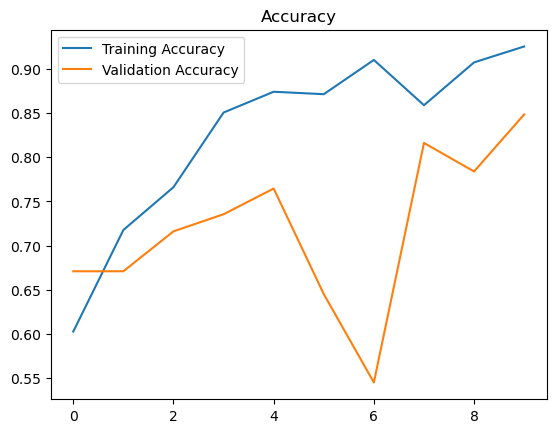

In [31]:
plot_metrics(history) 

In [36]:
loss_10, acc_10 = model.evaluate(x=X_test, y=y_test)

10/10 [==============================] - 18s 456ms/step - loss: 0.2839 - accuracy: 0.8935


In [38]:
print (f"Test Loss = {loss_10}")
print (f"Test Accuracy = {acc_10}")

Test Loss = 0.2839129865169525
Test Accuracy = 0.8935483694076538


# Results

Expérimentons avec le meilleur modèle (celui ayant la meilleure précision de validation) :

### Load the best model avec epochs=23

In [17]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=23, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {format_duree(execution_time)}")

Epoch 1/23


46/46 [==============================] - ETA: 0s - loss: 0.9773 - accuracy: 0.6069
Epoch 1: val_accuracy improved from -inf to 0.56129, saving model to models\cnn-parameters-improvement-01-0.56.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-01-0.56.model\assets


INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-01-0.56.model\assets


46/46 [==============================] - 66s 1s/step - loss: 0.9773 - accuracy: 0.6069 - val_loss: 0.6660 - val_accuracy: 0.5613
Epoch 2/23
46/46 [==============================] - ETA: 0s - loss: 0.5314 - accuracy: 0.7419
Epoch 2: val_accuracy improved from 0.56129 to 0.70000, saving model to models\cnn-parameters-improvement-02-0.70.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-02-0.70.model\assets


INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-02-0.70.model\assets


46/46 [==============================] - 54s 1s/step - loss: 0.5314 - accuracy: 0.7419 - val_loss: 0.6007 - val_accuracy: 0.7000
Epoch 3/23
46/46 [==============================] - ETA: 0s - loss: 0.4630 - accuracy: 0.7869
Epoch 3: val_accuracy improved from 0.70000 to 0.78387, saving model to models\cnn-parameters-improvement-03-0.78.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-03-0.78.model\assets


...

INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-08-0.89.model\assets


46/46 [==============================] - 50s 1s/step - loss: 0.2684 - accuracy: 0.8969 - val_loss: 0.3257 - val_accuracy: 0.8871
Epoch 9/23
46/46 [==============================] - ETA: 0s - loss: 0.2424 - accuracy: 0.9066
Epoch 9: val_accuracy did not improve from 0.88710
46/46 [==============================] - 50s 1s/step - loss: 0.2424 - accuracy: 0.9066 - val_loss: 0.4420 - val_accuracy: 0.7968
Epoch 10/23
46/46 [==============================] - ETA: 0s - loss: 0.2405 - accuracy: 0.9045
Epoch 10: val_accuracy did not improve from 0.88710
46/46 [==============================] - 45s 988ms/step - loss: 0.2405 - accuracy: 0.9045 - val_loss: 0.3192 - val_accuracy: 0.8677
Epoch 11/23
46/46 [==============================] - ETA: 0s - loss: 0.2561 - accuracy: 0.8893
Epoch 11: val_accuracy did not improve from 0.88710
46/46 [==============================] - 53s 1s/step - loss: 0.2561 - accuracy: 0.8893 - val_loss: 0.3110 - val_accuracy: 0.8774
Epoch 12/23
46/46 [=======================

INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-21-0.92.model\assets


46/46 [==============================] - 61s 1s/step - loss: 0.1116 - accuracy: 0.9647 - val_loss: 0.2749 - val_accuracy: 0.9161
Epoch 22/23
46/46 [==============================] - ETA: 0s - loss: 0.0979 - accuracy: 0.9730
Epoch 22: val_accuracy did not improve from 0.91613
46/46 [==============================] - 50s 1s/step - loss: 0.0979 - accuracy: 0.9730 - val_loss: 0.2639 - val_accuracy: 0.9129
Epoch 23/23
46/46 [==============================] - ETA: 0s - loss: 0.0855 - accuracy: 0.9772
Epoch 23: val_accuracy did not improve from 0.91613
46/46 [==============================] - 50s 1s/step - loss: 0.0855 - accuracy: 0.9772 - val_loss: 0.3220 - val_accuracy: 0.8968


NameError: name 'format_duree' is not defined

### plot loss et accuracy 

In [33]:
history_ = model.history.history

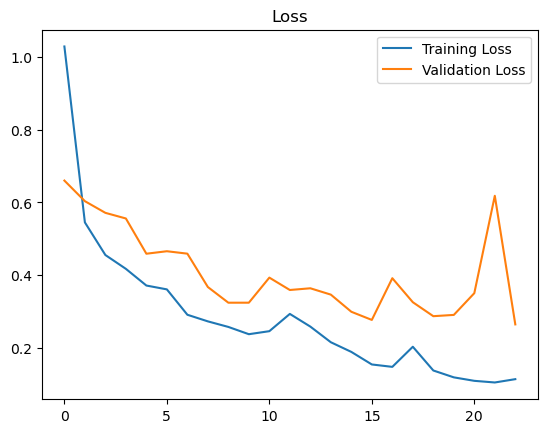

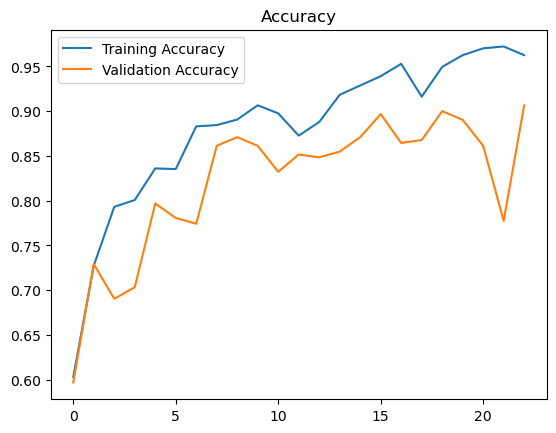

In [36]:
plot_metrics(history_)

In [18]:
from tensorflow.keras.models import load_model

best_model = load_model(filepath='models/cnn-parameters-improvement-22-0.90.model')


In [19]:
best_model.metrics_names

['loss', 'accuracy']

<h2>Evaluate the best model on the testing data:</h2>

In [20]:
loss, acc = best_model.evaluate(x=X_test, y=y_test)

10/10 [==============================] - 3s 298ms/step - loss: 0.0817 - accuracy: 0.9774


### Accuracy of the best model on the testing data:

In [21]:
print (f"Test Loss = {loss}")
print (f"Test Accuracy = {acc}")

Test Loss = 0.08172471076250076
Test Accuracy = 0.977419376373291


### F1 score for the best model on the testing data:

In [22]:
y_test_prob = best_model.predict(X_test)

10/10 [==============================] - 3s 274ms/step


In [23]:
from sklearn.metrics import f1_score

f1score = compute_f1_score(y_test, y_test_prob)
print(f"F1 score: {f1score}")

F1 score: 0.9793510324483775


### F1 score for the best model on the validation data:

In [24]:
y_val_prob = best_model.predict(X_val)

10/10 [==============================] - 3s 281ms/step


In [25]:
f1score_val = compute_f1_score(y_val, y_val_prob)
print(f"F1 score: {f1score_val}")

F1 score: 0.987012987012987


**Performance Table:**

| <!-- -->  | Validation set | Test set |
| --------- | -------------- | -------- |
| Accuracy  |   97%          |     98%  |
| F1 score  | 0.97           | 0.98     |

In [1]:
import tensorflow as tf
from PIL import Image
import numpy as np
from ipywidgets import FileUpload, Output, VBox, Button
from IPython.display import display, clear_output
import io
from keras.models import load_model
best_model = load_model(filepath='models/cnn-parameters-improvement-22-0.90.model')


def predict_image(img_array):
    img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)

    # Redimensionner l'image à la taille attendue par le modèle
    img_array = tf.image.resize(img_array, (240, 240))

    img_array = img_array / 255.0
    img_array = tf.expand_dims(img_array, axis=0)

    # Faire une prédiction avec le modèle chargé
    prediction = best_model.predict(img_array)

    return "Tumeur détectée" if prediction[0][0] > 0.5 else "Pas de tumeur détectée"



# Fonction appelée lorsqu'une image est téléchargée
def on_upload(change):
    with output:
        clear_output(wait=True)
        for uploaded_file in uploader.value:
            filename = uploaded_file.name
            contents = uploaded_file.content
            img = Image.open(io.BytesIO(contents)).resize((224, 224)).convert("RGB")  # Redimensionner à (224, 224)
            img_array = np.array(img)
            result = predict_image(img_array)
            print(f'Résultat pour {filename}: {result}')


# Créer un widget d'upload
uploader = FileUpload()

# Créer un bouton pour lancer la prédiction
button_predict = Button(description="Prédire")
button_predict.on_click(on_upload)

# Zone de sortie pour afficher les résultats
output = Output()

# Afficher les widgets
VBox([uploader, button_predict, output])